# Step 6  
Input: s3://thesis--ec331-s3/capped-volume-bids/  
Output: s3://thesis--ec331-s3/capped-volume-bids/  

In [1]:
import pandas as pd
import boto3
from io import BytesIO

def list_s3_files(bucket_name, prefix):
    """
    List all files in an S3 bucket with the given prefix
    
    Parameters:
    bucket_name (str): Name of the S3 bucket
    prefix (str): Prefix to filter objects
    
    Returns:
    list: List of S3 object keys matching the prefix
    """
    s3 = boto3.client('s3')
    
    # List objects with the given prefix
    result = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
    
    # Check if there are any objects
    if 'Contents' not in result:
        return []
    
    # Extract the keys
    files = [obj['Key'] for obj in result['Contents'] if obj['Key'].endswith('.parquet') or obj['Key'].endswith('.snappy.parquet')]
    
    return files

def read_all_parquet_from_s3(s3_path):
    """
    Read all parquet files from an S3 directory
    
    Parameters:
    s3_path (str): S3 path to the directory
    
    Returns:
    pandas.DataFrame: Combined DataFrame from all parquet files
    """
    # Parse the S3 path
    if s3_path.startswith('s3://'):
        s3_path = s3_path[5:]  # Remove the 's3://' prefix
    
    # Split into bucket and prefix
    parts = s3_path.split('/', 1)
    bucket = parts[0]
    prefix = parts[1] if len(parts) > 1 else ''
    
    # Get list of parquet files
    file_keys = list_s3_files(bucket, prefix)
    
    print(f"Found {len(file_keys)} parquet files in {s3_path}")
    
    # Read each file and combine
    dfs = []
    s3 = boto3.resource('s3')
    
    for key in file_keys:
        print(f"Reading file: {key}")
        obj = s3.Object(bucket, key)
        df = pd.read_parquet(BytesIO(obj.get()['Body'].read()))
        dfs.append(df)
    
    # Combine all dataframes
    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True)
        return combined_df
    else:
        print("No parquet files found")
        return pd.DataFrame()

# Alternate implementation using pyarrow for better performance with large files
def read_all_parquet_with_pyarrow(s3_path):
    """
    Read all parquet files from an S3 directory using pyarrow
    
    Parameters:
    s3_path (str): S3 path to the directory
    
    Returns:
    pandas.DataFrame: Combined DataFrame from all parquet files
    """
    import pyarrow.parquet as pq
    import pyarrow as pa
    from pyarrow import fs
    
    # Create S3 filesystem
    s3 = fs.S3FileSystem()
    
    # Get dataset
    dataset = pq.ParquetDataset(s3_path, filesystem=s3)
    
    # Read as table and convert to pandas
    table = dataset.read()
    df = table.to_pandas()
    
    return df

# For AWS Glue or EMR environments, you can also use:
def read_with_spark(s3_path):
    """
    Read parquet files using Spark (for AWS Glue or EMR environments)
    
    Parameters:
    s3_path (str): S3 path to the directory
    
    Returns:
    pandas.DataFrame: DataFrame from Spark
    """
    from pyspark.sql import SparkSession
    
    # Create Spark session
    spark = SparkSession.builder.appName("ReadParquet").getOrCreate()
    
    # Read parquet data
    spark_df = spark.read.parquet(s3_path)
    
    # Convert to pandas
    pandas_df = spark_df.toPandas()
    
    # Stop Spark session
    spark.stop()
    
    return pandas_df

# For direct use without AWS credentials (if using IAM roles or configured AWS CLI):
def simple_s3_parquet_reader(s3_path):
    """
    Simple function to read parquet files directly from S3 path
    
    Parameters:
    s3_path (str): Full S3 path including s3:// prefix
    
    Returns:
    pandas.DataFrame: Combined DataFrame
    """
    return pd.read_parquet(s3_path)

# Example usage
if __name__ == "__main__":
    # Define the S3 directory path
    s3_dir = 's3://thesis--ec331-s3/merged-price-volume-bids/2023-10-20_to_2023-10-21/TRADINGDATE=2023-10-20 00:00:00/'
    
    # Choose one of these methods depending on your environment and needs:
    
    # Method 1: Using boto3 and pandas
    # df = read_all_parquet_from_s3(s3_dir)
    
    # Method 2: Using pyarrow (faster for large datasets)
    df = read_all_parquet_with_pyarrow(s3_dir)
    
    # Method 3: Using Spark (for AWS Glue or EMR)
    # df = read_with_spark(s3_dir)
    
    # Method 4: Simple direct read (if permissions are set up)
    # df = simple_s3_parquet_reader(s3_dir)
    
    # Display general information about the DataFrame
    print("DataFrame Info:")
    df.info()
    
    # Show the first few rows of the DataFrame
    print("\nDataFrame Head:")
    print(df.head())
    
    # Show the last few rows of the DataFrame
    print("\nDataFrame Tail:")
    print(df.tail())
    
    # Display descriptive statistics for numerical columns
    print("\nDataFrame Description:")
    print(df.describe(include='all'))
    
    # List all column names
    print("\nDataFrame Columns:")
    print(df.columns.tolist())
    
    # Calculate VWAP metrics
    # Calculate average bid price
    avg_bid_price = df['BIDPRICE'].mean()
    
    # Calculate average bid volume
    avg_bid_volume = df['BIDVOLUME'].mean()
    
    # Calculate volume weighted average bid price (VWAP)
    non_zero_volume_df = df[df['BIDVOLUME'] > 0]
    vwap = (non_zero_volume_df['BIDPRICE'] * non_zero_volume_df['BIDVOLUME']).sum() / non_zero_volume_df['BIDVOLUME'].sum()
    
    print("\nMetrics:")
    print(f"Average Bid Price: {avg_bid_price:.2f}")
    print(f"Average Bid Volume: {avg_bid_volume:.2f}")
    print(f"Volume Weighted Average Price: {vwap:.2f}")

ArrowInvalid: Expected an S3 object path of the form 'bucket/key...', got a URI: 's3://thesis--ec331-s3/merged-price-volume-bids/2023-10-20_to_2023-10-21/TRADINGDATE=2023-10-20 00:00:00/'

Average Bid Price: 1544.40
Average Bid Volume: 0.20
Volume Weighted Average Price: 14990.00

VWAP by Bid Type:
  RAISE1SEC: 14990.00
VWAP over time plot saved as 'vwap_over_time.png'


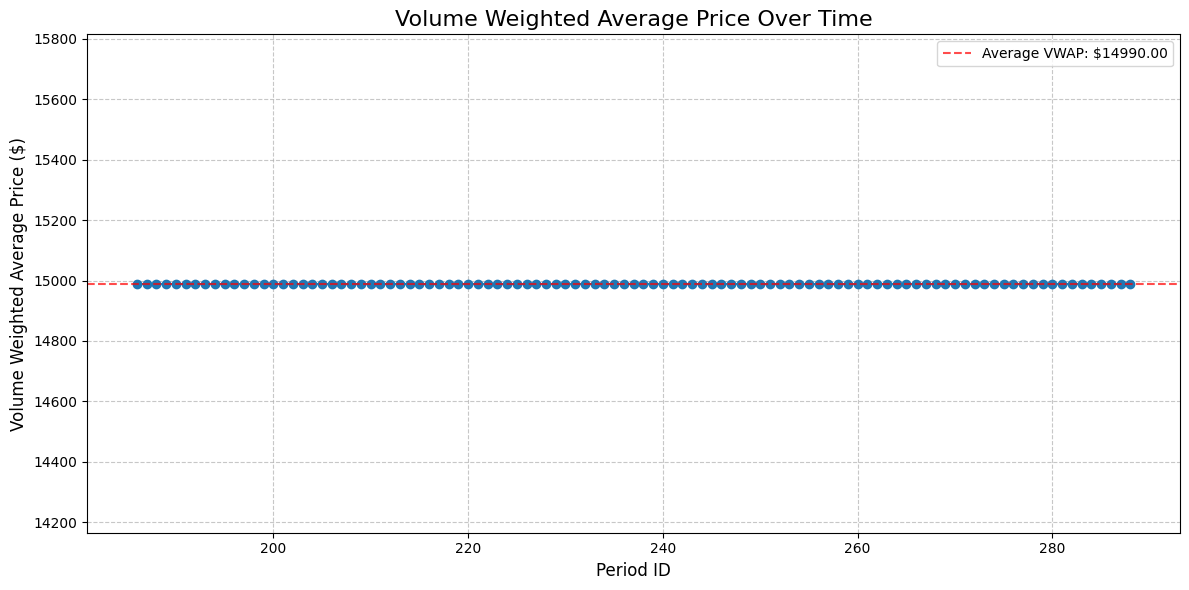

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def analyze_bids(file_path):
    """
    Analyze bid data from a parquet file to calculate key metrics:
    - Average bid price
    - Average bid volume
    - Volume weighted average bid price
    
    Parameters:
    file_path (str): Path to the parquet file
    
    Returns:
    dict: Dictionary containing the calculated metrics
    """
    # Read the parquet file
    df = pd.read_parquet(file_path)
    
    # Calculate average bid price
    avg_bid_price = df['BIDPRICE'].mean()
    
    # Calculate average bid volume
    avg_bid_volume = df['BIDVOLUME'].mean()
    
    # Calculate volume weighted average bid price (VWAP)
    # First, ensure we don't divide by zero by filtering out zero volumes
    non_zero_volume_df = df[df['BIDVOLUME'] > 0]
    
    # Calculate VWAP: sum(price * volume) / sum(volume)
    vwap = (non_zero_volume_df['BIDPRICE'] * non_zero_volume_df['BIDVOLUME']).sum() / non_zero_volume_df['BIDVOLUME'].sum()
    
    # Calculate VWAP by BIDTYPE
    vwap_by_bid_type = {}
    for bid_type in df['BIDTYPE'].unique():
        type_df = df[(df['BIDTYPE'] == bid_type) & (df['BIDVOLUME'] > 0)]
        if not type_df.empty and type_df['BIDVOLUME'].sum() > 0:
            type_vwap = (type_df['BIDPRICE'] * type_df['BIDVOLUME']).sum() / type_df['BIDVOLUME'].sum()
            vwap_by_bid_type[bid_type] = type_vwap
    
    # Return results as a dictionary
    results = {
        'average_bid_price': avg_bid_price,
        'average_bid_volume': avg_bid_volume,
        'volume_weighted_average_price': vwap,
        'vwap_by_bid_type': vwap_by_bid_type
    }
    
    return results, df

def analyze_vwap_by_time(df, time_column='PERIODID', interval='hour'):
    """
    Calculate VWAP by time period
    
    Parameters:
    df (DataFrame): DataFrame containing bid data
    time_column (str): Column name containing time information
    interval (str): Time interval to group by ('hour', 'day', etc.)
    
    Returns:
    DataFrame: DataFrame with VWAP by time period
    """
    # Make sure we only consider non-zero volumes
    non_zero_df = df[df['BIDVOLUME'] > 0].copy()
    
    # Calculate the weighted value for each row
    non_zero_df['weighted_value'] = non_zero_df['BIDPRICE'] * non_zero_df['BIDVOLUME']
    
    # Group by the time column
    grouped = non_zero_df.groupby(time_column).agg({
        'weighted_value': 'sum',
        'BIDVOLUME': 'sum'
    })
    
    # Calculate VWAP for each time period
    grouped['vwap'] = grouped['weighted_value'] / grouped['BIDVOLUME']
    
    return grouped

def plot_vwap_by_time(vwap_time_df, title="Volume Weighted Average Price Over Time"):
    """
    Plot VWAP over time without using seaborn
    
    Parameters:
    vwap_time_df (DataFrame): DataFrame with VWAP by time period
    title (str): Plot title
    
    Returns:
    Figure: Matplotlib figure object
    """
    plt.figure(figsize=(12, 6))
    
    # Set a grid background using just matplotlib
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot the VWAP over time
    plt.plot(vwap_time_df.index, vwap_time_df['vwap'], marker='o', linestyle='-', color='#1f77b4')
    
    plt.title(title, fontsize=16)
    plt.xlabel('Period ID', fontsize=12)
    plt.ylabel('Volume Weighted Average Price ($)', fontsize=12)
    
    # Add average line
    avg_vwap = vwap_time_df['vwap'].mean()
    plt.axhline(y=avg_vwap, color='r', linestyle='--', alpha=0.7, 
                label=f'Average VWAP: ${avg_vwap:.2f}')
    
    plt.legend()
    plt.tight_layout()
    
    return plt.gcf()

def analyze_multiple_files(file_paths):
    """
    Analyze multiple parquet files and aggregate the results.
    
    Parameters:
    file_paths (list): List of paths to parquet files
    
    Returns:
    dict: Dictionary containing the aggregated metrics
    """
    # Initialize variables for aggregation
    total_value = 0
    total_volume = 0
    total_price_sum = 0
    total_volume_sum = 0
    all_dfs = []
    
    # Process each file
    for path in file_paths:
        df = pd.read_parquet(path)
        all_dfs.append(df)
        
        # Add to running totals
        total_price_sum += df['BIDPRICE'].sum()
        total_volume_sum += df['BIDVOLUME'].sum()
        
        # Add to weighted sum for VWAP
        non_zero_volume_df = df[df['BIDVOLUME'] > 0]
        total_value += (non_zero_volume_df['BIDPRICE'] * non_zero_volume_df['BIDVOLUME']).sum()
        total_volume += non_zero_volume_df['BIDVOLUME'].sum()
    
    # Combine all DataFrames
    combined_df = pd.concat(all_dfs)
    
    # Calculate aggregated metrics
    avg_bid_price = total_price_sum / combined_df.shape[0]
    avg_bid_volume = total_volume_sum / combined_df.shape[0]
    vwap = total_value / total_volume if total_volume > 0 else 0
    
    results = {
        'average_bid_price': avg_bid_price,
        'average_bid_volume': avg_bid_volume,
        'volume_weighted_average_price': vwap
    }
    
    return results, combined_df

# Example usage
if __name__ == "__main__":
    # Define the file path
    file_path = 's3://thesis--ec331-s3/merged-price-volume-bids/2023-10-20_to_2023-10-21/TRADINGDATE=2023-10-20 00:00:00/a6ec7cd5446346478fbae27246d161f0.snappy.parquet'
    
    # Analyze the data
    results, df = analyze_bids(file_path)
    
    # Print the results
    print(f"Average Bid Price: {results['average_bid_price']:.2f}")
    print(f"Average Bid Volume: {results['average_bid_volume']:.2f}")
    print(f"Volume Weighted Average Price: {results['volume_weighted_average_price']:.2f}")
    
    print("\nVWAP by Bid Type:")
    for bid_type, vwap in results['vwap_by_bid_type'].items():
        print(f"  {bid_type}: {vwap:.2f}")
    
    # Calculate VWAP by time period
    vwap_time_df = analyze_vwap_by_time(df)
    
    # Plot VWAP over time
    fig = plot_vwap_by_time(vwap_time_df)
    
    # Save the figure
    fig.savefig('vwap_over_time.png', dpi=300, bbox_inches='tight')
    print("VWAP over time plot saved as 'vwap_over_time.png'")
    
    # Example of analyzing multiple files
    # file_paths = ['path1.parquet', 'path2.parquet', 'path3.parquet']
    # multi_results, combined_df = analyze_multiple_files(file_paths)
    # vwap_time_df_multi = analyze_vwap_by_time(combined_df)
    # fig_multi = plot_vwap_by_time(vwap_time_df_multi, title="VWAP Over Time (Multiple Files)")
    # fig_multi.savefig('vwap_over_time_multi.png', dpi=300, bbox_inches='tight')